In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_csv("Hybrid_Deficit_Condition.csv")

print(df.shape)
print(df.head())


(1000, 10)
   Time (s)  Motor_Power_Demand (kW)  Battery_Power (kW)  FuelCell_Power (kW)  \
0         0                16.504693           -3.495307                 20.0   
1         1                16.319991           -3.680009                 20.0   
2         2                23.906150            3.906150                 20.0   
3         3                20.969549            0.969549                 20.0   
4         4                27.507669            7.507669                 20.0   

   Battery_SOC (%)  Battery_Voltage (V)  Battery_Current (A)  \
0        80.000000           545.682532            -6.405385   
1        80.003680           550.090084            -6.689830   
2        79.999774           543.165708             7.191451   
3        79.998804           536.478042             1.807249   
4        79.991297           547.558631            13.711169   

   FuelCell_Voltage (V)  Vehicle_Speed (km/h)  Acceleration  
0            799.687965             10.460962      5.63

In [ ]:
df_train = df.iloc[:1000].copy()


In [ ]:
features = [
   "Battery_Power (kW)"
]

target = "FuelCell_Power (kW)"


In [ ]:
def create_lagged_data(df, features, target, lag=100):
    X, y = [], []

    for i in range(lag, len(df)):
        X.append(df[features].iloc[i-lag:i].values.flatten())
        y.append(df[target].iloc[i])

    return np.array(X), np.array(y)

lag = 100
X_train, y_train = create_lagged_data(df_train, features, target, lag)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [ ]:
model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
last_window = df_train[features].iloc[-lag:].values.flatten()

future_predictions = []

for i in range(1000):

    # Scale input
    input_scaled = scaler.transform(last_window.reshape(1, -1))

    # Predict next value
    next_pred = model.predict(input_scaled)[0]

    future_predictions.append(next_pred)

    # Update window
    new_row = df_train[features].iloc[-1].values.copy()
    new_row[0] = next_pred  # update Motor Power only

    last_window = np.append(last_window[len(features):], new_row)


In [ ]:
future_time = np.arange(1000, 2000)


In [ ]:
original_time = df_train["Time (s)"]
original_power = df_train[target]

combined_time = np.concatenate([original_time, future_time])
combined_power = np.concatenate([original_power, future_predictions])


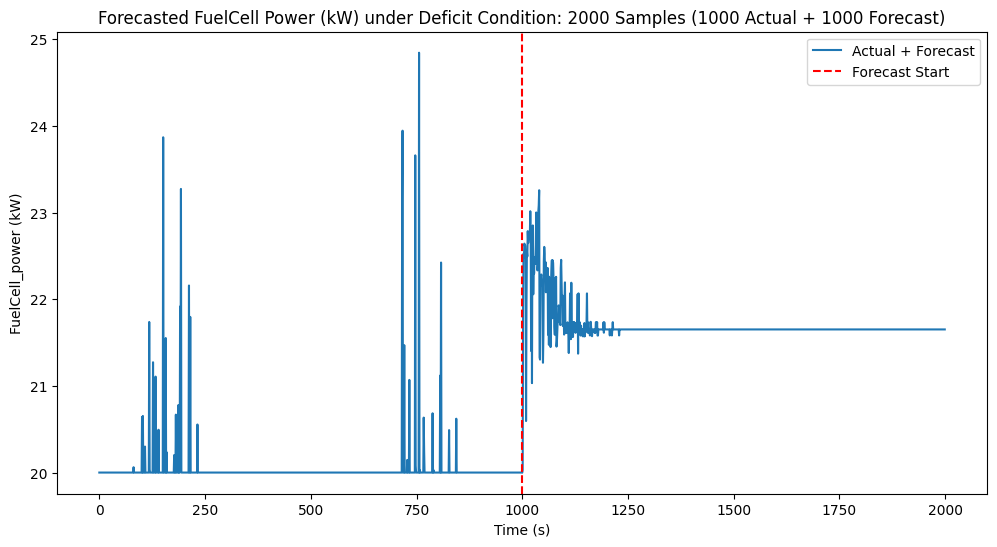

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(combined_time, combined_power, label="Actual + Forecast")
plt.axvline(x=999, color='r', linestyle='--', label='Forecast Start')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("FuelCell_power (kW)")
plt.title("Forecasted FuelCell Power (kW) under Deficit Condition: 2000 Samples (1000 Actual + 1000 Forecast)")
plt.show()


In [ ]:
features = [
   "Battery_Power (kW)"
]

target = "Battery_Power (kW)"


In [ ]:
def create_lagged_data(df, features, target, lag=100):
    X, y = [], []

    for i in range(lag, len(df)):
        X.append(df[features].iloc[i-lag:i].values.flatten())
        y.append(df[target].iloc[i])

    return np.array(X), np.array(y)

lag = 100
X_train, y_train = create_lagged_data(df_train, features, target, lag)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [ ]:
model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
last_window = df_train[features].iloc[-lag:].values.flatten()

future_predictions = []

for i in range(1000):

    # Scale input
    input_scaled = scaler.transform(last_window.reshape(1, -1))

    # Predict next value
    next_pred = model.predict(input_scaled)[0]

    future_predictions.append(next_pred)

    # Update window
    new_row = df_train[features].iloc[-1].values.copy()
    new_row[0] = next_pred  # update Motor Power only

    last_window = np.append(last_window[len(features):], new_row)


In [ ]:
original_time = df_train["Time (s)"]
original_power = df_train[target]

combined_time = np.concatenate([original_time, future_time])
combined_power = np.concatenate([original_power, future_predictions])


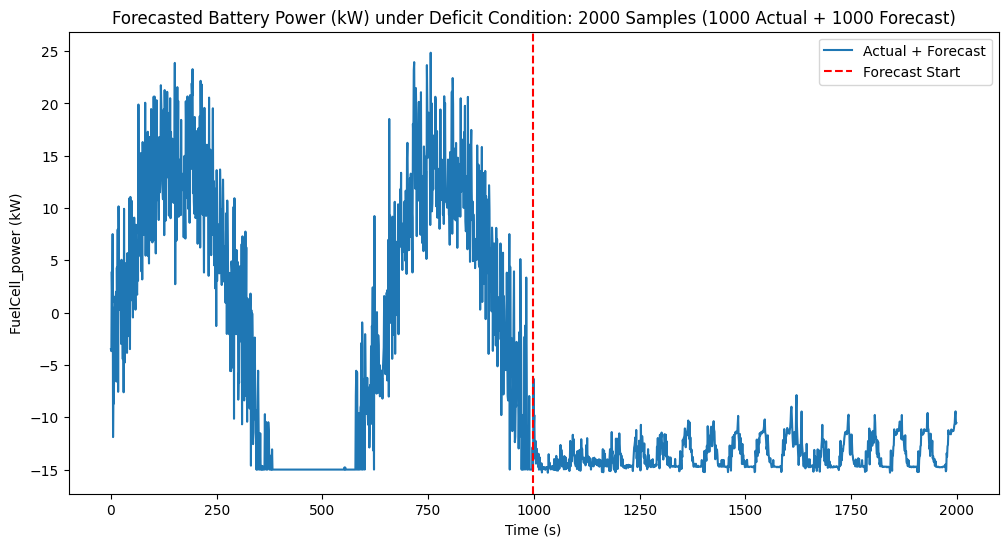

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(combined_time, combined_power, label="Actual + Forecast")
plt.axvline(x=999, color='r', linestyle='--', label='Forecast Start')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("FuelCell_power (kW)")
plt.title("Forecasted Battery Power (kW) under Deficit Condition: 2000 Samples (1000 Actual + 1000 Forecast)")
plt.show()


Saving Hybrid_Deficit_Condition.csv to Hybrid_Deficit_Condition (1).csv


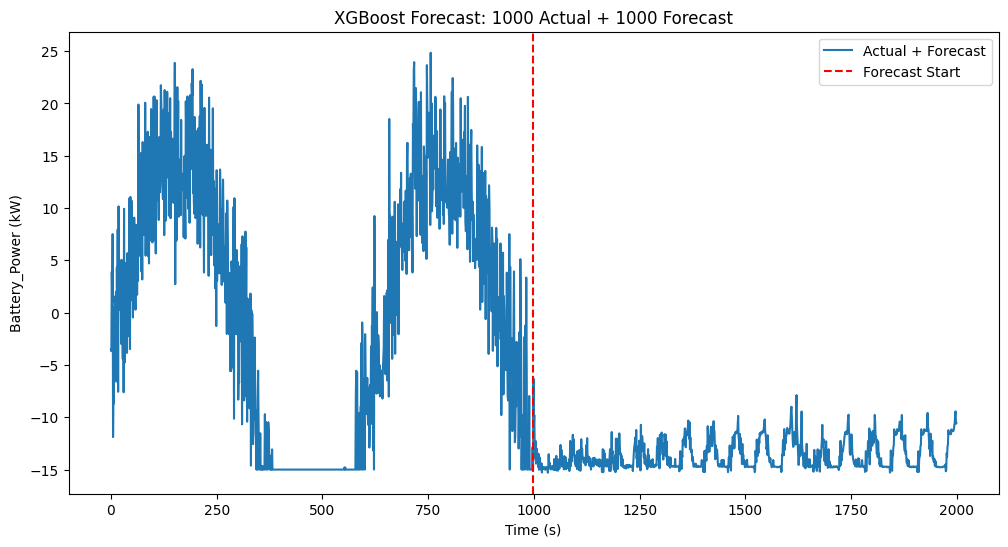